# Categorizar y añadir métricas

#### Importar librerias

In [1]:
pip install mplsoccer

In [2]:
import pandas as pd

#### Importar datos - STATSBOMB

In [3]:
df_events = pd.read_csv('/content/drive/MyDrive/MIS_ANÁLISIS/PROFESIONAL/Visualizaciones/Statsbomb_Events_DB.csv', low_memory=False)

In [4]:
df_events.head()

,id,index,period,timestamp,minute,second,possession,duration,match_id,type_id,...,foul_committed_offensive,ball_recovery_offensive,x_scaled,y_scaled,end_x_scaled,end_y_scaled,progressive_pass,quick_recovery_x,quick_recovery_y,quick_recovery
0,093f898d-33b1-4425-b591-37dd9c9bf70b,1,1,00:00:00,0,0,1,0.000000,3857256,35,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN
1,79a9efbb-b5e5-45b0-983d-8729bcc4a0e1,2,1,00:00:00,0,0,1,0.000000,3857256,35,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN
2,c4cdfc71-b9f4-4751-a714-e816c1419457,3,1,00:00:00,0,0,1,0.000000,3857256,18,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN
3,51f295b8-da96-428e-ab47-90f380f8cf53,4,1,00:00:00,0,0,1,0.000000,3857256,18,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN
4,4acb4fd2-f46a-4d73-993c-e06597873924,5,1,00:00:00.521000,0,0,2,1.220932,3857256,30,...,NaN,NaN,50.833333,50.125,35.916667,54.625,False,NaN,NaN,NaN


## 1. Pases progresivos

#### Detectar los pases progresivos

In [5]:
# Paso 1: Calculamos la distancia progresiva (avance en X)
df_events['x_difference'] = df_events['end_x_scaled'] - df_events['x_scaled']

In [6]:
# Paso 2: Creamos una columna 'pase_progresivo' con el mismo estilo de filtro compacto
df_events['progressive_pass'] = ((df_events['type_name'] == 'Pass') & (
                                    ((df_events['x_scaled'] <= 34) & (df_events['x_difference'] > 20))     # PRIMER TERCIO DE CAMPO
                                      | ((df_events['x_scaled'] <= 68) & (df_events['x_difference'] > 15)) # MEDIO CAMPO
                                      | ((df_events['x_scaled']  > 68) & (df_events['x_difference'] > 10)) # ÚLTIMO TERCIO DE CAMPO
                                    )
                                )

df_events.drop('x_difference', axis=1, inplace=True)

In [33]:
# Guardamos los datos con la nueva columna calculada
#df_events.to_csv('/content/drive/MyDrive/MIS_ANÁLISIS/PROFESIONAL/Visualizaciones/Statsbomb_Events_DB_categorizados.csv', index=False)

In [7]:
df_events.head()

,id,index,period,timestamp,minute,second,possession,duration,match_id,type_id,...,foul_committed_offensive,ball_recovery_offensive,x_scaled,y_scaled,end_x_scaled,end_y_scaled,progressive_pass,quick_recovery_x,quick_recovery_y,quick_recovery
0,093f898d-33b1-4425-b591-37dd9c9bf70b,1,1,00:00:00,0,0,1,0.000000,3857256,35,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN
1,79a9efbb-b5e5-45b0-983d-8729bcc4a0e1,2,1,00:00:00,0,0,1,0.000000,3857256,35,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN
2,c4cdfc71-b9f4-4751-a714-e816c1419457,3,1,00:00:00,0,0,1,0.000000,3857256,18,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN
3,51f295b8-da96-428e-ab47-90f380f8cf53,4,1,00:00:00,0,0,1,0.000000,3857256,18,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN
4,4acb4fd2-f46a-4d73-993c-e06597873924,5,1,00:00:00.521000,0,0,2,1.220932,3857256,30,...,NaN,NaN,50.833333,50.125,35.916667,54.625,False,NaN,NaN,NaN


#### Categorizar los pases progresivos

In [8]:
df_progressive_passes = df_events[df_events['progressive_pass']==True].reset_index(drop=True)

In [9]:
df_progressive_passes['outcome_name'] = df_progressive_passes['outcome_name'].replace({'Out': 'Missed', 'Incomplete': 'Missed', 'Injury Clearance': 'Missed', 'Unknown': 'Missed', 'Pass Offside': 'Missed'})
df_progressive_passes['outcome_name'] = df_progressive_passes['outcome_name'].fillna('Successful')

In [10]:
df_progressive_passes = df_progressive_passes[0:10]

#### Visualizar los pases progresivos

In [11]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch

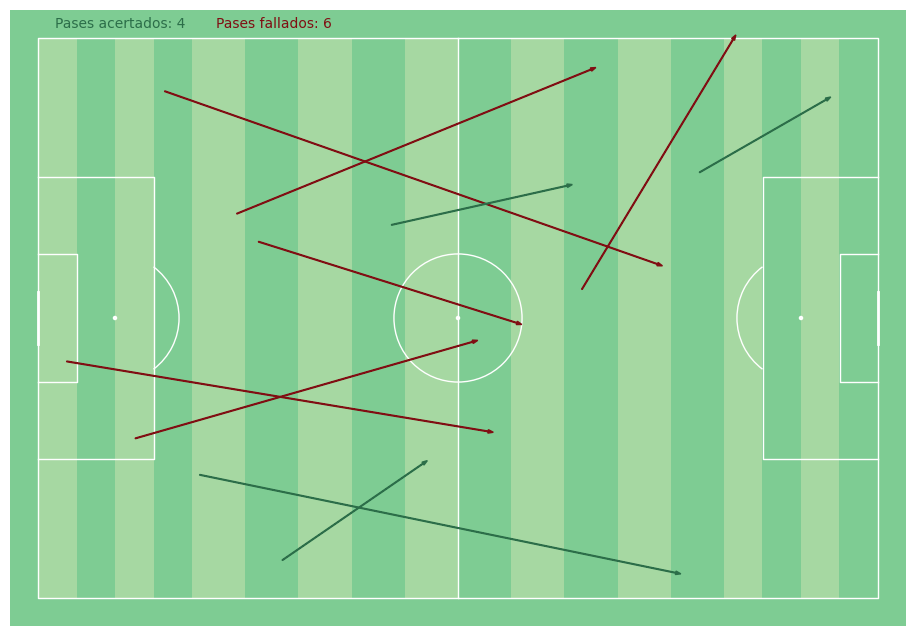

In [12]:
fig, ax = plt.subplots(figsize=(15,8))

legend = {'Successful': '#2c6e49','Missed': '#800e13'}

pitch = Pitch(pitch_type='custom', half=False, pitch_color='#7ECC93', line_color='white', linewidth=1,
              stripe=True, stripe_color='#A6D8A2', pitch_length=120, pitch_width=80, goal_type='line', label=False)

pitch.draw(ax=ax)

ax.invert_yaxis()  # Y coordinates are reversed

# Dibujamos los pases como flechas
for i in range(len(df_progressive_passes['player_name'])):
    plt.arrow(df_progressive_passes['x'][i], df_progressive_passes['y'][i],
              df_progressive_passes['end_x'][i] - df_progressive_passes['x'][i],
              df_progressive_passes['end_y'][i] - df_progressive_passes['y'][i],
              head_width=0.5, width=0.1,
              ec=df_progressive_passes['outcome_name'].map(legend)[i],
              color=df_progressive_passes['outcome_name'].map(legend)[i],
              alpha=1)

# Contamos los pases
num_completados = (df_progressive_passes['outcome_name'] == 'Successful').sum()
num_fallados = (df_progressive_passes['outcome_name'] == 'Missed').sum()

# Añadimos texto arriba a la derecha con colores del legend
ax.text(
    21, -3,  # posición fuera del campo (ajusta si hace falta)
    f"Pases acertados: {num_completados}",
    ha='right', va='top',
    fontsize=10, color=legend['Successful'])

ax.text(
    42, -3,  # un poco más abajo para el segundo texto
    f"Pases fallados: {num_fallados}",
    ha='right', va='top',
    fontsize=10, color=legend['Missed'])

plt.show()

## 2. Recuperaciones rápidas

In [13]:
df_quick_recoveries = df_events[df_events['type_name'] == 'Ball Recovery'].copy()
df_quick_recoveries = df_quick_recoveries.sort_values(['match_id', 'index'], ascending=[True, True]).reset_index(drop=True)

In [14]:
df_quick_recoveries['prev_team'] = df_quick_recoveries['team_name'].shift(1)
df_quick_recoveries['prev_recovery_opp_team'] = (df_quick_recoveries['team_name'] != df_quick_recoveries['prev_team'])

In [15]:
df_quick_recoveries['seconds'] = df_quick_recoveries['minute'] * 60 + df_quick_recoveries['second']
df_quick_recoveries['prev_seconds'] = df_quick_recoveries['seconds'].shift(1)
df_quick_recoveries['time_difference'] = df_quick_recoveries['seconds'] - df_quick_recoveries['prev_seconds']

In [16]:
df_quick_recoveries['quick_recovery'] = ((df_quick_recoveries['prev_recovery_opp_team'] == True) &
                                         (df_quick_recoveries['time_difference'].between(0, 5)))

In [17]:
# Filtrar solo las recuperaciones rápidas y resetear el índice
df_quick_recoveries = df_quick_recoveries[df_quick_recoveries['quick_recovery'] == True].reset_index(drop=True)

In [18]:
df_quick_recoveries[['match_id','team_name','timestamp','prev_team','prev_recovery_opp_team','time_difference','quick_recovery']].head(5)

,match_id,team_name,timestamp,prev_team,prev_recovery_opp_team,time_difference,quick_recovery
0,3857256,Switzerland,00:09:07.702000,Serbia,True,5.0,True
1,3857256,Serbia,00:28:49.031000,Switzerland,True,4.0,True
2,3857256,Serbia,00:09:59.556000,Switzerland,True,3.0,True
3,3857256,Serbia,00:25:42.804000,Switzerland,True,0.0,True
4,3857256,Switzerland,00:30:30.578000,Serbia,True,2.0,True


In [19]:
df_events = df_events.merge(df_quick_recoveries[['match_id', 'index', 'quick_recovery']], on=['match_id', 'index'], how='left')

MergeError: Passing 'suffixes' which cause duplicate columns {'quick_recovery_x'} is not allowed.

In [24]:
df_events[df_events['quick_recovery']==True].head()

,id,index,period,timestamp,minute,second,possession,duration,match_id,type_id,...,foul_committed_offensive,ball_recovery_offensive,x_scaled,y_scaled,end_x_scaled,end_y_scaled,progressive_pass,quick_recovery_x,quick_recovery_y,quick_recovery
316,822c1dd4-f1e7-4c1e-8797-52a3ab8f1d7f,316,1,00:09:07.702000,9,7,22,0.0,3857256,2,...,NaN,NaN,1.500000,74.250,NaN,NaN,False,True,True,True
1011,2c0ddd99-0360-4424-a66d-54ad6fae6090,1011,1,00:28:49.031000,28,49,71,0.0,3857256,2,...,NaN,NaN,59.250000,26.375,NaN,NaN,False,True,True,True
1835,16aaaf93-35ad-428b-b9b7-f0922809ee9e,1836,2,00:09:59.556000,54,59,125,0.0,3857256,2,...,NaN,NaN,77.750000,19.875,NaN,NaN,False,True,True,True
2237,63e7642c-06eb-4c89-aea2-aeb449a06684,2238,2,00:25:42.804000,70,42,153,0.0,3857256,2,...,NaN,NaN,53.083333,44.000,NaN,NaN,False,True,True,True
2480,62ec0e31-3686-4de1-88ed-18fb1282e778,2481,2,00:30:30.578000,75,30,160,0.0,3857256,2,...,NaN,NaN,79.083333,11.375,NaN,NaN,False,True,True,True


In [ ]:
#df_events.to_csv('./Statsbomb_Events_DB.csv', index=False)

#### Visualizar las recuperaciones rápidas

In [22]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch

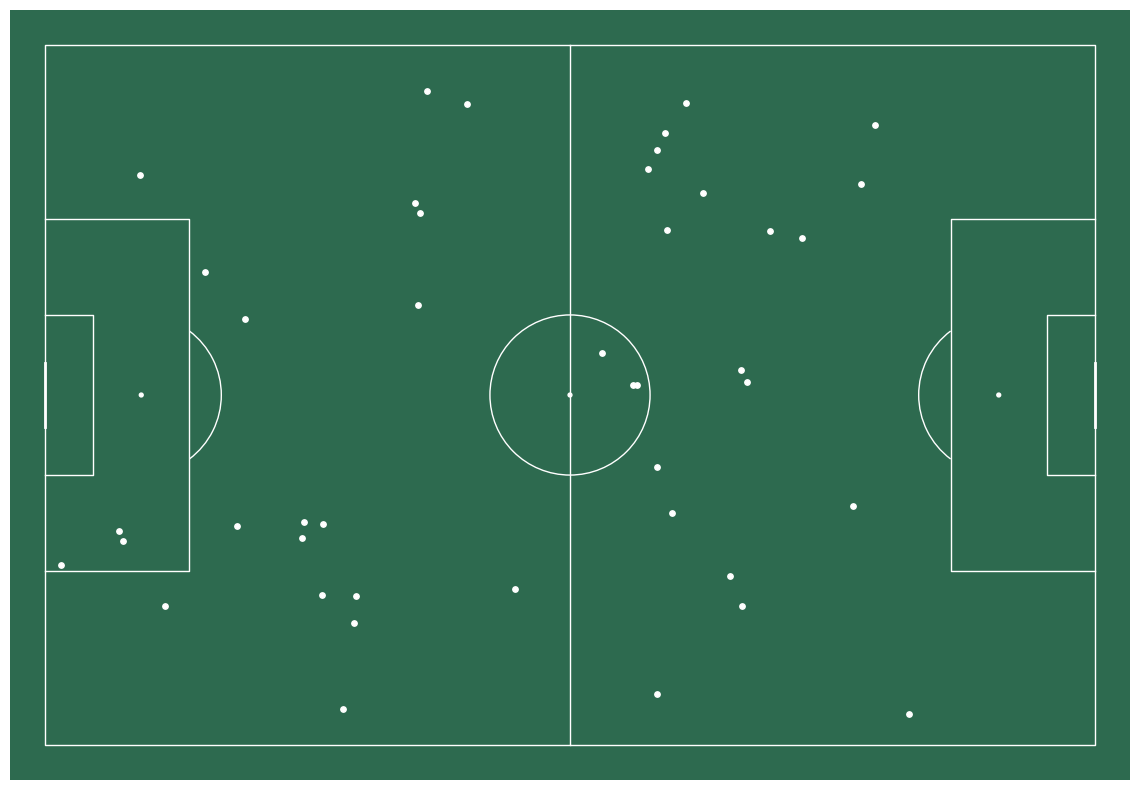

In [23]:
fig, ax = plt.subplots(figsize=(15,8), dpi=100)

# Plot the pitch
pitch = Pitch(pitch_type='custom', half = False, pitch_color='#2d6a4f', line_color='white', linewidth = 1,
              pitch_length=120, pitch_width=80, goal_type='line', label=False)

pitch.draw(ax=ax)
ax.invert_yaxis() # Invert Y axis

#Dibujamos el punto de inicio de los pases
pitch.scatter(x = df_quick_recoveries['x'], y = df_quick_recoveries['y'], color = 'white', s = 15, marker = "o", ax=ax)

plt.tight_layout()

## 3. Estadísticas agregadas

In [26]:
df_events.columns.to_list()

['id',
 'index',
 'period',
 'timestamp',
 'minute',
 'second',
 'possession',
 'duration',
 'match_id',
 'type_id',
 'type_name',
 'possession_team_id',
 'possession_team_name',
 'play_pattern_id',
 'play_pattern_name',
 'team_id',
 'team_name',
 'tactics_formation',
 'player_id',
 'player_name',
 'position_id',
 'position_name',
 'pass_recipient_id',
 'pass_recipient_name',
 'pass_length',
 'pass_angle',
 'pass_height_id',
 'pass_height_name',
 'end_x',
 'end_y',
 'body_part_id',
 'body_part_name',
 'sub_type_id',
 'sub_type_name',
 'x',
 'y',
 'pass_cross',
 'outcome_id',
 'outcome_name',
 'under_pressure',
 'shot_statsbomb_xg',
 'technique_id',
 'technique_name',
 'shot_first_time',
 'goalkeeper_position_id',
 'goalkeeper_position_name',
 'pass_assisted_shot_id',
 'pass_shot_assist',
 'end_z',
 'shot_key_pass_id',
 'off_camera',
 'pass_deflected',
 'counterpress',
 'aerial_won',
 'pass_switch',
 'out',
 'foul_won_defensive',
 'shot_one_on_one',
 'pass_cut_back',
 'block_offensive',

#### Agregar por jugador

In [27]:
df_aggregated_player_stats = (df_events.groupby(['player_name','team_name'])['type_name'].value_counts().unstack(fill_value=0)).reset_index()

In [28]:
df_aggregated_player_stats.sort_values(by='Pass',ascending=False).head(5)

type_name,player_name,team_name,Pass,Ball Receipt,Carry,Pressure,Ball Recovery,Duel,Clearance,Block,...,Substitution,Injury Stoppage,Bad Behaviour,50/50,Error,Goal Keeper,Shield,Own Goal Against,Player Off,Player On
0,Aaron Mooy,Australia,152,102,102,34,23,14,9,5,...,0,0,0,0,0,0,0,0,0,0
16,Aziz Eraltay Behich,Australia,138,102,96,27,13,5,2,10,...,0,0,0,1,0,0,0,0,0,0
62,Kye Rowles,Australia,134,92,79,31,3,7,8,7,...,0,1,0,0,1,0,0,0,0,0
73,Mathew Ryan,Australia,130,62,68,0,15,0,1,0,...,0,2,0,0,0,51,0,0,0,0
106,Strahinja Pavlović,Serbia,125,101,95,26,13,4,7,4,...,0,1,0,0,1,0,0,0,0,0


#### Agregar por equipo

In [29]:
#convertir cada valor que hay en type_name a columna
df_aggregated_team_stats = (df_events.groupby(['team_name'])['type_name'].value_counts().unstack(fill_value=0)).reset_index()

In [30]:
df_aggregated_team_stats.sort_values(by='Pass',ascending=False).head(5)

type_name,team_name,50/50,Bad Behaviour,Ball Receipt,Ball Recovery,Block,Carry,Clearance,Dispossessed,Dribble,...,Pass,Player Off,Player On,Pressure,Referee Ball-Drop,Shield,Shot,Starting XI,Substitution,Tactical Shift
1,Australia,8,0,1132,126,86,800,74,26,39,...,1232,1,1,444,2,2,22,3,14,8
4,Serbia,1,4,880,88,42,712,28,22,16,...,967,1,1,241,4,1,17,2,10,3
0,Argentina,0,0,711,47,13,646,25,4,23,...,728,0,0,127,1,0,14,1,5,3
3,Denmark,1,0,679,49,22,591,27,6,18,...,715,0,0,101,0,0,14,1,5,1
2,Brazil,1,0,575,56,16,547,22,10,22,...,618,0,0,102,1,1,23,1,5,2


#### Añadir métricas calculadas

In [32]:
calculated_events = ['progressive_pass']
calculated_event_counts = (df_events.groupby(['player_name', 'team_name'])[calculated_events].sum()).reset_index()

In [33]:
calculated_event_counts.head()

,player_name,team_name,progressive_pass
0,Aaron Mooy,Australia,37
1,Ajdin Hrustic,Australia,4
2,Alejandro Darío Gómez,Argentina,2
3,Aleksandar Mitrović,Serbia,2
4,Alex Sandro Lobo Silva,Brazil,13


In [34]:
df_aggregated_player_stats = df_aggregated_player_stats.merge(calculated_event_counts[['player_name', 'team_name'] + calculated_events], on=['player_name', 'team_name'], how='left')


In [35]:
df_aggregated_player_stats.head()

,player_name,team_name,Pass,Ball Receipt,Carry,Pressure,Ball Recovery,Duel,Clearance,Block,...,Injury Stoppage,Bad Behaviour,50/50,Error,Goal Keeper,Shield,Own Goal Against,Player Off,Player On,progressive_pass
0,Aaron Mooy,Australia,152,102,102,34,23,14,9,5,...,0,0,0,0,0,0,0,0,0,37
1,Ajdin Hrustic,Australia,23,38,27,23,4,2,2,0,...,0,0,0,0,0,0,0,0,0,4
2,Alejandro Darío Gómez,Argentina,33,37,36,7,2,0,0,0,...,0,0,0,0,0,0,0,0,0,2
3,Aleksandar Mitrović,Serbia,45,79,31,13,3,14,1,2,...,2,1,0,0,0,0,0,0,0,2
4,Alex Sandro Lobo Silva,Brazil,90,72,71,8,5,2,5,1,...,0,0,0,0,0,0,0,0,0,13


In [36]:
df_aggregated_player_stats.fillna(0)

,player_name,team_name,Pass,Ball Receipt,Carry,Pressure,Ball Recovery,Duel,Clearance,Block,...,Injury Stoppage,Bad Behaviour,50/50,Error,Goal Keeper,Shield,Own Goal Against,Player Off,Player On,progressive_pass
0,Aaron Mooy,Australia,152,102,102,34,23,14,9,5,...,0,0,0,0,0,0,0,0,0,37
1,Ajdin Hrustic,Australia,23,38,27,23,4,2,2,0,...,0,0,0,0,0,0,0,0,0,4
2,Alejandro Darío Gómez,Argentina,33,37,36,7,2,0,0,0,...,0,0,0,0,0,0,0,0,0,2
3,Aleksandar Mitrović,Serbia,45,79,31,13,3,14,1,2,...,2,1,0,0,0,0,0,0,0,2
4,Alex Sandro Lobo Silva,Brazil,90,72,71,8,5,2,5,1,...,0,0,0,0,0,0,0,0,0,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,Wahbi Khazri,Tunisia,10,13,9,4,2,3,0,0,...,0,0,0,0,0,0,0,0,0,2
112,Wajdi Kechrida,Tunisia,18,12,8,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,3
113,Xherdan Shaqiri,Switzerland,24,39,23,7,1,5,0,0,...,0,0,0,0,0,0,0,0,0,7
114,Yassine Meriah,Tunisia,80,64,61,9,10,5,10,4,...,0,0,1,0,0,0,0,0,0,15
